In [27]:
import earthaccess
import xarray as xr
import rioxarray


In [28]:
earthaccess.login()

In [29]:
datasets = earthaccess.search_datasets(
    short_name = 'SPL2SMAP_S',
    version = '003'
)
print(len(datasets))
print(datasets[0].summary())

1
{'short-name': 'SPL2SMAP_S', 'concept-id': 'C2938663471-NSIDC_CPRD', 'version': '003', 'file-type': "[{'FormatType': 'Native', 'Format': 'HDF5', 'FormatDescription': 'HTTPS'}]", 'get-data': ['https://search.earthdata.nasa.gov/search/granules?p=C2938663471-NSIDC_CPRD', 'https://cmr.earthdata.nasa.gov/virtual-directory/collections/C2938663471-NSIDC_CPRD', 'https://nsidc.org/data/data-access-tool/SPL2SMAP_S/versions/3/', 'https://earthaccess.readthedocs.io/en/stable/'], 'cloud-info': {'Region': 'us-west-2', 'S3BucketAndObjectPrefixNames': ['nsidc-cumulus-prod-protected/SMAP/SPL2SMAP_S/003', 'nsidc-cumulus-prod-public/SMAP/SPL2SMAP_S/003'], 'S3CredentialsAPIEndpoint': 'https://data.nsidc.earthdatacloud.nasa.gov/s3credentials', 'S3CredentialsAPIDocumentationURL': 'https://data.nsidc.earthdatacloud.nasa.gov/s3credentialsREADME'}}


/var/folders/jv/vkj2kxvs7vs4lb9_8bnqgr2h0000gn/T/ipykernel_97685/2937587256.py:6: FutureWarning: As of version 1.0, `DataCollection.summary` will be accessed as an attribute; e.g. use `DataCollection.summary` **not** `DataCollection.summary()`
  print(datasets[0].summary())


In [30]:
data = earthaccess.search_data(
    short_name = 'SPL2SMAP_S',
    version = '003',
    temporal = ('2023-10-01', '2024-01-01'),
    point = (-68.86417, -20.26568)
)
print(len(data))

27


/opt/miniconda3/envs/SMAP/lib/python3.13/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


In [31]:
ds = earthaccess.open(data)

/opt/miniconda3/envs/SMAP/lib/python3.13/site-packages/earthaccess/store.py:523: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)
QUEUEING TASKS | : 100%|██████████| 27/27 [00:00<00:00, 5995.99it/s]
PROCESSING TASKS | : 100%|██████████| 27/27 [00:09<00:00,  2.73it/s]
COLLECTING RESULTS | : 100%|██████████| 27/27 [00:00<00:00, 274869.44it/s]


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

In [33]:
# Define the target coordinates
target_lon = -68.86417
target_lat = -20.26568

time_series_dates = []
soil_moisture_values = []

In [34]:
# # CHANGED: WE NO LONGER PRE-OPEN ALL DATA WITH earthaccess.open(data)
# # Instead, we loop directly through the metadata list 'data'
# for index, granule_metadata in enumerate(data):
    
#     granule_name = granule_metadata['umm']['DataGranule']['Identifiers'][0]['Identifier']
    
#     # Print progress every 10 granules so the console doesn't get flooded during a 3-year run
#     if index % 10 == 0:
#         print(f"Processing granule {index + 1}/{len(data)}: {granule_name}")
    
#     try:
#         # CHANGED: OPEN ONLY ONE SINGLE GRANULE AT A TIME
#         # earthaccess.open() returns a list, so we take the first element [0]
#         with earthaccess.open([granule_metadata])[0] as file_handle:
            
#             # Using xarray inside the 'with' block ensures the cloud connection 
#             # closes automatically as soon as the block ends, freeing memory
#             granule_dataset = xr.open_dataset(
#                 file_handle, 
#                 group='Soil_Moisture_Retrieval_Data_3km', 
#                 engine='h5netcdf',
#                 phony_dims='sort'
#             )

#             # Extract the 2D arrays for latitude and longitude
#             latitudes = granule_dataset['latitude_3km'].values
#             longitudes = granule_dataset['longitude_3km'].values

#             # Calculate the squared euclidean distance to find the nearest pixel index
#             distance_squared = (latitudes - target_lat)**2 + (longitudes - target_lon)**2
#             nearest_pixel_index = np.unravel_index(
#                 np.argmin(distance_squared, axis=None), 
#                 distance_squared.shape
#             )

#             # Extract the soil moisture value for the target pixel
#             pixel_soil_moisture = granule_dataset['soil_moisture_3km'].values[nearest_pixel_index]

#             # Filter out invalid values and fill values
#             if pixel_soil_moisture != -9999.0 and not np.isnan(pixel_soil_moisture):
                
#                 # Extract date directly from granule filename
#                 filename_parts = granule_name.split('_')
#                 date_string_raw = filename_parts[6]
#                 granule_datetime = pd.to_datetime(date_string_raw, format='%Y%m%dT%H%M%S')

#                 # Store the valid data
#                 time_series_dates.append(granule_datetime)
#                 soil_moisture_values.append(pixel_soil_moisture)

#     except Exception as error:
#         # Keep track of failed connections, but allow the loop to continue with the next years
#         print(f"WARNING: Skipping granule {granule_name} due to error: {error}")

In [36]:
# VERSION PARA POCOS DATOS

# Iterate through the metadata granules and the opened file handlers simultaneously
for granule_metadata, file_handle in zip(data, ds):
    
    # EXTRACTED GRANULE NAME FOR BETTER DEBUGGING MESSAGES
    granule_name = granule_metadata['umm']['DataGranule']['Identifiers'][0]['Identifier']
    print(f"\nProcessing granule: {granule_name}")
    
    try:
        # Open the specific HDF5 group containing the 3km resolution variables
        granule_dataset = xr.open_dataset(
            file_handle, 
            group='Soil_Moisture_Retrieval_Data_3km', 
            engine='h5netcdf'
        )

        # Extract the 2D arrays for latitude and longitude
        latitudes = granule_dataset['latitude_3km'].values
        longitudes = granule_dataset['longitude_3km'].values

        # Calculate the squared euclidean distance to find the nearest pixel index
        distance_squared = (latitudes - target_lat)**2 + (longitudes - target_lon)**2
        nearest_pixel_index = np.unravel_index(
            np.argmin(distance_squared, axis=None), 
            distance_squared.shape
        )
        
        # ADDED PRINT TO CHECK THE MINIMUM DISTANCE TO ENSURE THE PIXEL IS ACTUALLY CLOSE
        min_distance = np.sqrt(np.min(distance_squared))
        print(f"Nearest pixel distance: {min_distance:.4f} degrees")

        # Extract the soil moisture value for the target pixel
        pixel_soil_moisture = granule_dataset['soil_moisture_3km'].values[nearest_pixel_index]
        
        # ADDED PRINT TO SEE THE RAW PIXEL VALUE BEFORE FILTERING
        print(f"Raw soil moisture value: {pixel_soil_moisture}")

        # Filter out invalid values and fill values
        if pixel_soil_moisture != -9999.0 and not np.isnan(pixel_soil_moisture):
            
            # Extract the temporal information directly from granule filename
            filename_parts = granule_name.split('_')
            date_string_raw = filename_parts[6]  # Contains '20231003T101216'
            granule_datetime = pd.to_datetime(date_string_raw, format='%Y%m%dT%H%M%S')

            # Store the valid data
            time_series_dates.append(granule_datetime)
            soil_moisture_values.append(pixel_soil_moisture)
            
            # ADDED PRINT TO CONFIRM WHEN A VALID VALUE IS SUCCESSFULLY ADDED
            print(f"SUCCESS: Added valid value {pixel_soil_moisture} for date {granule_datetime}")
            
        else:
            # ADDED PRINT TO NOTIFY IF THE VALUE WAS FILTERED OUT AS INVALID/FILL VALUE
            print("Filtered: Value is invalid (-9999.0 or NaN). No valid observation here.")

    except Exception as error:
        # CHANGED TO PRINT THE EXCEPTION INSTEAD OF SILENTLY PASSING TO CATCH CRASHES
        print(f"ERROR: Failed to process this granule. Reason: {error}")


Processing granule: SMAP_L2_SM_SP_1AIWDV_20231003T101216_20231004T230739_068W19S_R18290_001.h5


/var/folders/jv/vkj2kxvs7vs4lb9_8bnqgr2h0000gn/T/ipykernel_97685/3425465779.py:12: UserWarning: The 'phony_dims' kwarg now defaults to 'access'. Previously 'phony_dims=None' would raise an error. For full netcdf equivalence please use phony_dims='sort'.
  granule_dataset = xr.open_dataset(


Nearest pixel distance: 0.0109 degrees
Raw soil moisture value: 0.02199999988079071
SUCCESS: Added valid value 0.02199999988079071 for date 2023-10-04 23:07:39

Processing granule: SMAP_L2_SM_SP_1AIWDV_20231003T101216_20231004T230714_068W21S_R18290_001.h5


/var/folders/jv/vkj2kxvs7vs4lb9_8bnqgr2h0000gn/T/ipykernel_97685/3425465779.py:12: UserWarning: The 'phony_dims' kwarg now defaults to 'access'. Previously 'phony_dims=None' would raise an error. For full netcdf equivalence please use phony_dims='sort'.
  granule_dataset = xr.open_dataset(


Nearest pixel distance: 0.0109 degrees
Raw soil moisture value: nan
Filtered: Value is invalid (-9999.0 or NaN). No valid observation here.

Processing granule: SMAP_L2_SM_SP_1AIWDV_20231006T102359_20231005T100056_067W20S_R18290_001.h5


...

/var/folders/jv/vkj2kxvs7vs4lb9_8bnqgr2h0000gn/T/ipykernel_97685/3425465779.py:12: UserWarning: The 'phony_dims' kwarg now defaults to 'access'. Previously 'phony_dims=None' would raise an error. For full netcdf equivalence please use phony_dims='sort'.
  granule_dataset = xr.open_dataset(


Nearest pixel distance: 0.0109 degrees
Raw soil moisture value: 0.02199999988079071
SUCCESS: Added valid value 0.02199999988079071 for date 2023-12-27 23:07:36

Processing granule: SMAP_L2_SM_SP_1AIWDV_20231228T103647_20231228T100054_067W20S_R19240_001.h5


/var/folders/jv/vkj2kxvs7vs4lb9_8bnqgr2h0000gn/T/ipykernel_97685/3425465779.py:12: UserWarning: The 'phony_dims' kwarg now defaults to 'access'. Previously 'phony_dims=None' would raise an error. For full netcdf equivalence please use phony_dims='sort'.
  granule_dataset = xr.open_dataset(


Nearest pixel distance: 0.0109 degrees
Raw soil moisture value: 0.019999999552965164
SUCCESS: Added valid value 0.019999999552965164 for date 2023-12-28 10:00:54

Processing granule: SMAP_L2_SM_SP_1AIWDV_20231228T103647_20231227T230711_068W21S_R19240_001.h5
Nearest pixel distance: 0.0109 degrees
Raw soil moisture value: nan
Filtered: Value is invalid (-9999.0 or NaN). No valid observation here.


/var/folders/jv/vkj2kxvs7vs4lb9_8bnqgr2h0000gn/T/ipykernel_97685/3425465779.py:12: UserWarning: The 'phony_dims' kwarg now defaults to 'access'. Previously 'phony_dims=None' would raise an error. For full netcdf equivalence please use phony_dims='sort'.
  granule_dataset = xr.open_dataset(


In [37]:
# Create a pandas dataframe for easier handling and plotting
soil_moisture_dataframe = pd.DataFrame({
    'date': time_series_dates,
    'soil_moisture': soil_moisture_values
})
print(f"\nFinal dataframe length: {len(soil_moisture_dataframe)}")

# Sort the dataframe chronologically to ensure the line plot is drawn correctly
soil_moisture_dataframe = soil_moisture_dataframe.sort_values('date')


Final dataframe length: 17


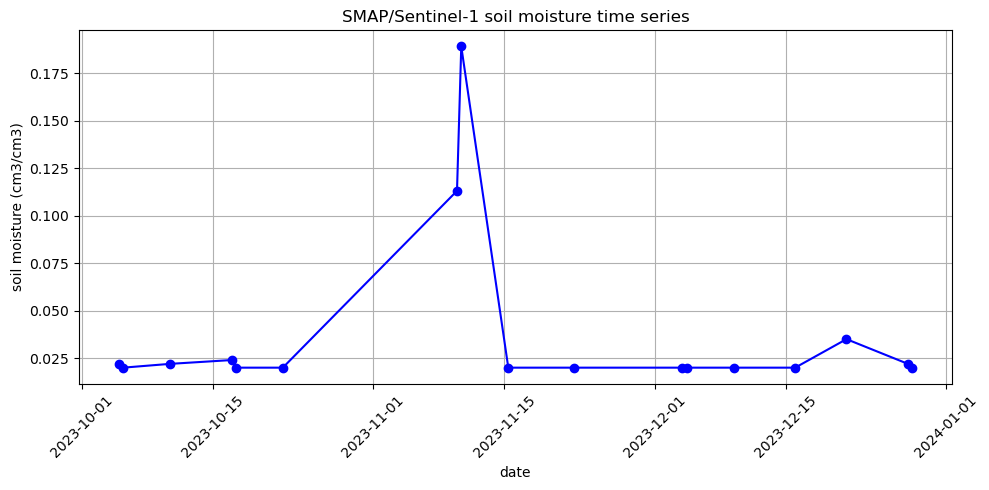

In [38]:
# Plot the time series
plt.figure(figsize=(10, 5))
plt.plot(
    soil_moisture_dataframe['date'], 
    soil_moisture_dataframe['soil_moisture'], 
    marker='o', 
    linestyle='-', 
    color='b'
)
plt.title('SMAP/Sentinel-1 soil moisture time series')
plt.xlabel('date')
plt.ylabel('soil moisture (cm3/cm3)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Processing batch: 2024-01-01 to 2024-01-31...


/opt/miniconda3/envs/SMAP/lib/python3.13/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
/opt/miniconda3/envs/SMAP/lib/python3.13/site-packages/earthaccess/store.py:523: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)
QUEUEING TASKS | : 100%|██████████| 14/14 [00:00<00:00, 10734.96it/s]
PROCESSING TASKS | : 100%|██████████| 14/14 [00:05<00:00,  2.47it/s]
COLLECTING RESULTS | : 100%|██████████| 14/14 [00:00<00:00, 85848.33it/s]


Processing batch: 2024-02-01 to 2024-02-29...


/opt/miniconda3/envs/SMAP/lib/python3.13/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
/opt/miniconda3/envs/SMAP/lib/python3.13/site-packages/earthaccess/store.py:523: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)
QUEUEING TASKS | : 100%|██████████| 9/9 [00:00<00:00, 2644.02it/s]
PROCESSING TASKS | : 100%|██████████| 9/9 [00:04<00:00,  2.10it/s]
COLLECTING RESULTS | : 100%|██████████| 9/9 [00:00<00:00, 134337.14it/s]


Processing batch: 2024-03-01 to 2024-03-31...


...

/opt/miniconda3/envs/SMAP/lib/python3.13/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
/opt/miniconda3/envs/SMAP/lib/python3.13/site-packages/earthaccess/store.py:523: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)
QUEUEING TASKS | : 100%|██████████| 11/11 [00:00<00:00, 3361.07it/s]
PROCESSING TASKS | : 100%|██████████| 11/11 [00:04<00:00,  2.50it/s]
COLLECTING RESULTS | : 100%|██████████| 11/11 [00:00<00:00, 183814.12it/s]


Processing batch: 2024-11-01 to 2024-11-30...


/opt/miniconda3/envs/SMAP/lib/python3.13/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
/opt/miniconda3/envs/SMAP/lib/python3.13/site-packages/earthaccess/store.py:523: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)
QUEUEING TASKS | : 100%|██████████| 12/12 [00:00<00:00, 4519.32it/s]
PROCESSING TASKS | : 100%|██████████| 12/12 [00:04<00:00,  2.68it/s]
COLLECTING RESULTS | : 100%|██████████| 12/12 [00:00<00:00, 158275.62it/s]


Processing batch: 2024-12-01 to 2024-12-31...


/opt/miniconda3/envs/SMAP/lib/python3.13/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()
/opt/miniconda3/envs/SMAP/lib/python3.13/site-packages/earthaccess/store.py:523: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)
QUEUEING TASKS | : 100%|██████████| 12/12 [00:00<00:00, 3319.59it/s]
PROCESSING TASKS | : 100%|██████████| 12/12 [00:04<00:00,  2.76it/s]
COLLECTING RESULTS | : 100%|██████████| 12/12 [00:00<00:00, 140985.01it/s]


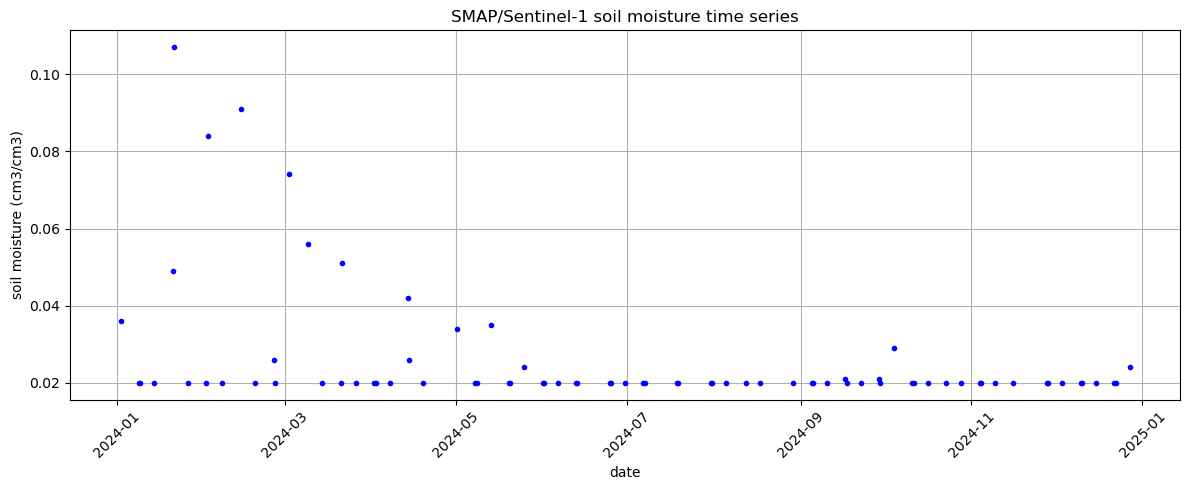

In [39]:
import earthaccess
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ENCAPSULATED THE ORIGINAL EXTRACTION LOGIC INTO A FUNCTION FOR MODULARITY
def extract_soil_moisture_batch(start_date, end_date, target_lon, target_lat):
    """
    Searches and extracts soil moisture time series for a specific short time window.
    """
    
    # ADDED THE SEARCH DATA FUNCTION INSIDE THE BATCH PROCESS TO ONLY QUERY SMALL PERIODS
    data = earthaccess.search_data(
        short_name='SPL2SMAP_S',
        version='003',
        temporal=(start_date, end_date),
        point=(target_lon, target_lat)
    )
    
    if not data:
        return [], []

    # OPEN FILES ONLY FOR THIS SPECIFIC BATCH
    ds = earthaccess.open(data)
    
    batch_dates = []
    batch_values = []

    # ORIGINAL EXTRACTION LOOP KEPT INTACT
    for granule_metadata, file_handle in zip(data, ds):
        granule_name = granule_metadata['umm']['DataGranule']['Identifiers'][0]['Identifier']
        
        try:
            granule_dataset = xr.open_dataset(
                file_handle, 
                group='Soil_Moisture_Retrieval_Data_3km', 
                engine='h5netcdf',
                phony_dims='sort'
            )

            latitudes = granule_dataset['latitude_3km'].values
            longitudes = granule_dataset['longitude_3km'].values

            distance_squared = (latitudes - target_lat)**2 + (longitudes - target_lon)**2
            nearest_pixel_index = np.unravel_index(
                np.argmin(distance_squared, axis=None), 
                distance_squared.shape
            )

            pixel_soil_moisture = granule_dataset['soil_moisture_3km'].values[nearest_pixel_index]

            if pixel_soil_moisture != -9999.0 and not np.isnan(pixel_soil_moisture):
                filename_parts = granule_name.split('_')
                date_string_raw = filename_parts[6]
                granule_datetime = pd.to_datetime(date_string_raw, format='%Y%m%dT%H%M%S')

                batch_dates.append(granule_datetime)
                batch_values.append(pixel_soil_moisture)
                
        except Exception as error:
            # SILENCED THE INDIVIDUAL GRANULE ERROR PRINT TO AVOID SPAMMING THE CONSOLE DURING YEARS OF DATA
            pass
            
    return batch_dates, batch_values

# CREATED A NEW FUNCTION TO MANAGE THE TEMPORAL ITERATION
def process_multi_year_series(start_year, end_year, target_lon, target_lat):
    """
    Generates monthly intervals and orchestrates the batch extraction.
    """
    
    all_dates = []
    all_values = []
    
    # GENERATE MONTHLY TIME INTERVALS USING PANDAS TO PREVENT SERVER OVERLOAD
    start_time_string = f"{start_year}-01-01"
    end_time_string = f"{end_year}-12-31"
    
    batch_start_dates = pd.date_range(start=start_time_string, end=end_time_string, freq='MS')
    batch_end_dates = pd.date_range(start=start_time_string, end=end_time_string, freq='ME')
    
    # ITERATE OVER EACH MONTH TO EXTRACT DATA INCREMENTALLY
    for batch_start, batch_end in zip(batch_start_dates, batch_end_dates):
        start_str = batch_start.strftime('%Y-%m-%d')
        end_str = batch_end.strftime('%Y-%m-%d')
        
        print(f"Processing batch: {start_str} to {end_str}...")
        
        extracted_dates, extracted_values = extract_soil_moisture_batch(
            start_str, end_str, target_lon, target_lat
        )
        
        all_dates.extend(extracted_dates)
        all_values.extend(extracted_values)
        
    final_dataframe = pd.DataFrame({
        'date': all_dates,
        'soil_moisture': all_values
    })
    
    return final_dataframe

# ENCAPSULATED THE PLOTTING LOGIC
def plot_multi_year_series(dataframe):
    """
    Plots the final consolidated dataframe.
    """
    if not dataframe.empty:
        dataframe = dataframe.sort_values('date')
        
        plt.figure(figsize=(12, 5))
        # REDUCED MARKER SIZE FOR BETTER VISUALIZATION OF DENSE MULTI-YEAR DATA
        plt.plot(dataframe['date'], dataframe['soil_moisture'], marker='o', linestyle='', color='b', markersize=3)
        plt.title('SMAP/Sentinel-1 soil moisture time series')
        plt.xlabel('date')
        plt.ylabel('soil moisture (cm3/cm3)')
        plt.grid(True)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print("No valid data points found in the entire series.")

# MAIN EXECUTION BLOCK
target_longitude = -68.86417
target_latitude = -20.26568

# DEFINE THE YEARS YOU WANT TO PROCESS
long_term_dataframe = process_multi_year_series(
    start_year=2024, 
    end_year=2024, 
    target_lon=target_longitude, 
    target_lat=target_latitude
)

plot_multi_year_series(long_term_dataframe)

In [40]:
long_term_dataframe

,date,soil_moisture
0,2024-01-02 10:09:03,0.036
1,2024-01-08 23:07:36,0.020
2,2024-01-09 10:00:53,0.020
3,2024-01-14 10:09:03,0.020
4,2024-01-20 23:07:36,0.049
...,...,...
73,2024-12-10 10:00:50,0.020
74,2024-12-15 10:09:00,0.020
75,2024-12-22 10:00:49,0.020
76,2024-12-21 23:07:13,0.020
